# Chapter 9 — Simple vs. Complex Contagion on Small-World Networks
**Modeling Social Behavior** | Smaldino

--- 

This notebook translates `SmallWorldDiffusion.nlogo` into Python.

It builds directly on the previous notebook (small-world network construction)
and adds a **contagion model** — an SI (Susceptible-Infected) process with
no recovery — run on top of the small-world network.

The key question: **how does rewiring probability affect the spread of
simple vs. complex contagion?**

- **Simple contagion**: one infected neighbor is enough to spread.
- **Complex contagion**: requires *two or more* infected neighbors simultaneously.

This produces the core result of section 9.4 and Figure 9.12:
more random long-range ties speed up simple contagion but *block* complex contagion.

## 1. Imports

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

## 2. Global Parameters

**Global variables** — set once, used throughout the model.

These match the NetLogo sliders and switch:
- `NUM_NODES`: population size. NetLogo slider: 100–500.
- `REWIRING_PROB`: p from the small-world algorithm. NetLogo slider: 0–1.
- `PROB_INFECTION`: transmissibility τ. NetLogo slider: 0–1.
  The BehaviorSpace experiments fix this at 1.0 (τ = 1), so all analyses here use τ = 1.
- `COMPLEX_CONTAGION`: True/False switch. NetLogo: on/off toggle.
- `DEGREE`: ring lattice degree, hardcoded at 4 in the NetLogo model.

In [2]:
# --- Global Parameters ---
NUM_NODES        = 500   # population size; NetLogo slider: 100 to 500
REWIRING_PROB    = 0.04  # rewiring probability p; NetLogo slider default: 0.04
PROB_INFECTION   = 1.0   # transmissibility τ; fixed at 1.0 in BehaviorSpace
COMPLEX_CONTAGION = False # False = simple, True = complex; NetLogo switch
DEGREE           = 4     # ring lattice degree; hardcoded in NetLogo

MAX_TICKS = 300  # time limit before declaring the simulation stopped
SEED      = 42   # for reproducibility

## 3. Network Builders (from previous notebook)

The diffusion model uses the same small-world network construction
as the previous notebook. Both functions are included here for
self-containedness.

In [3]:
def make_ring_lattice(num_nodes, degree=4):
    """
    Build a ring lattice — the starting structure before rewiring.
    Each node connects to its degree/2 nearest neighbors on each side.
    Translates `wire-lattice` from SmallWorldDiffusion.nlogo.
    """
    if degree >= num_nodes:
        degree = num_nodes - 1
    G = nx.Graph()
    G.add_nodes_from(range(num_nodes))
    for n in range(num_nodes):
        for k in range(1, degree // 2 + 1):
            G.add_edge(n, (n + k) % num_nodes)
    return G


def rewire_network(G, rewiring_prob, rng):
    """
    Apply Watts-Strogatz rewiring in-place.
    Translates `rewire-network` from SmallWorldDiffusion.nlogo.
    """
    for (u, v) in list(G.edges()):
        if not G.has_edge(u, v):
            continue
        if rng.random() < rewiring_prob:
            non_neighbors = [n for n in G.nodes() if n != u and not G.has_edge(u, n)]
            if non_neighbors:
                G.remove_edge(u, v)
                G.add_edge(u, rng.choice(non_neighbors))
    return G


def build_small_world(num_nodes, rewiring_prob, degree=4, seed=None):
    """
    Build a complete small-world network: ring lattice + rewiring.
    Mirrors the NetLogo `setup` procedure (network part only).
    """
    # Local variable: rng — seeded random number generator.
    rng = np.random.default_rng(seed)
    G = make_ring_lattice(num_nodes, degree)
    rewire_network(G, rewiring_prob, rng)
    return G

## 4. Agent State

### Agent-level variable: `infected?`

In the NetLogo model, each turtle owns a Boolean variable `infected?`.
In Python we represent the full population's infection state as a
**dictionary mapping node ID → True/False**.

This is the Python equivalent of `turtles-own [infected?]`.

### Global variable: `num_infected`

NetLogo tracks `num-infected` as a global counter updated each tick.
In Python we compute it on the fly as `sum(infected.values())`.

## 5. `infect_two()` — Initializing the Contagion

At setup, the model infects exactly two neighboring agents to seed the contagion.

**NetLogo `infect-two` logic:**
```
ask one-of turtles [
  set infected? true
  ask one-of link-neighbors [
    set infected? true
  ]
]
set num-infected 2
```

Picking two *neighbors* (not two random nodes) is important:
it ensures the complex contagion model has a chance to get started,
since complex contagion requires *two* infected neighbors. If the two
seeds were unconnected, complex contagion would never spread from either.

In [4]:
def infect_two(G, rng):
    """
    Seed the contagion by infecting one random node and one of its neighbors.

    Translates `infect-two` from SmallWorldDiffusion.nlogo.

    Parameters
    ----------
    G   : nx.Graph
    rng : np.random.Generator

    Returns
    -------
    infected : dict  {node_id: bool}
               Agent-level variable: True if infected, False if susceptible.
    """
    # Initialize all agents as susceptible.
    # Agent-level variable: infected? = False for all nodes.
    infected = {n: False for n in G.nodes()}

    # Pick one random node as the first seed.
    # NetLogo: `ask one-of turtles [ set infected? true ... ]`
    # Local variable: seed_node.
    seed_node = rng.choice(list(G.nodes()))
    infected[seed_node] = True

    # Infect one of its neighbors as the second seed.
    # NetLogo: `ask one-of link-neighbors [ set infected? true ]`
    # Using a neighbor (not a random node) ensures the two seeds share an edge,
    # which is required for complex contagion to have any hope of spreading.
    neighbors = list(G.neighbors(seed_node))
    if neighbors:
        infected[rng.choice(neighbors)] = True

    return infected

## 6. `go()` — One Time Step of Contagion Spread

This is the main dynamics procedure. On each tick, every infected agent
attempts to infect each of its susceptible neighbors.

**NetLogo `go` logic:**
```
ask turtles with [infected? = true] [
  ask link-neighbors with [not infected?] [
    if (random-float 1 <= prob-infection AND
        (not complex-contagion? OR
         count link-neighbors with [infected? = true] > 1))
    [ set infected? true ]
  ]
]
```

**Two conditions must both be met for infection to occur:**
1. A random draw falls below `prob_infection` (transmissibility τ).
2. If `complex_contagion` is True, the target must have **more than 1**
   infected neighbor *at the current time step*.

**Why copy the infected dict before the loop?**
We use `new_infected = dict(infected)` and write changes to it, reading
infection status from the original `infected`. This ensures that nodes
infected *during* this tick don't immediately spread in the same tick —
all transmissions are based on the state at the *start* of the tick.
This matches how NetLogo processes `ask turtles`: the agentset is determined
at the start and each turtle acts based on the state as it was at that moment.

In [5]:
def go(G, infected, prob_infection, complex_contagion, rng):
    """
    Execute one time step of SI contagion on the network.

    Translates the `go` procedure from SmallWorldDiffusion.nlogo.

    Parameters
    ----------
    G                 : nx.Graph
    infected          : dict {node: bool}  — current infection state
    prob_infection    : float — transmissibility τ; probability of infection per contact
    complex_contagion : bool  — if True, requires >1 infected neighbor to spread
    rng               : np.random.Generator

    Returns
    -------
    new_infected : dict {node: bool} — updated infection state after this tick
    """
    # Copy the current state — all reads use `infected`, all writes go to `new_infected`.
    # This prevents within-tick feedback (nodes infected this tick can't spread this tick).
    new_infected = dict(infected)

    # Iterate over all currently infected nodes.
    # NetLogo: `ask turtles with [infected? = true]`
    for node in G.nodes():
        if not infected[node]:
            continue  # skip susceptible agents

        # Attempt to infect each susceptible neighbor.
        # NetLogo: `ask link-neighbors with [not infected?]`
        for neighbor in G.neighbors(node):
            if infected[neighbor]:
                continue  # already infected; skip

            # --- Complex contagion threshold check ---
            # Count how many of this neighbor's connections are infected RIGHT NOW
            # (reading from `infected`, not `new_infected`).
            # NetLogo: `count link-neighbors with [infected? = true]`
            # Local variable: infected_nbr_count.
            infected_nbr_count = sum(
                1 for nn in G.neighbors(neighbor) if infected[nn]
            )

            # The infection happens if:
            # (1) random draw <= prob_infection  (transmissibility roll)
            # (2) simple contagion OR target already has >1 infected neighbor
            # NetLogo: `random-float 1 <= prob-infection AND
            #           (not complex-contagion? OR count ... > 1)`
            passes_threshold = (not complex_contagion) or (infected_nbr_count > 1)

            if rng.random() <= prob_infection and passes_threshold:
                new_infected[neighbor] = True

    return new_infected

## 7. `run_simulation()` — Full Run Until Saturation or Time Limit

Wraps `infect_two` + repeated `go` calls. Stops when either:
- All agents are infected (`all? turtles [infected?]` in NetLogo), or
- `MAX_TICKS` is reached (the NetLogo BehaviorSpace sets `timeLimit steps=300`).

Returns `(ticks, pct_infected)` — the two metrics tracked in the BehaviorSpace experiments.

In [6]:
def run_simulation(G, prob_infection, complex_contagion,
                   max_ticks=300, seed=None):
    """
    Run one full SI contagion simulation on network G.

    Mirrors the NetLogo BehaviorSpace setup:
      setup: infect-two
      go:    spread (one tick at a time)
      stop:  when all infected OR max_ticks reached

    Parameters
    ----------
    G                 : nx.Graph
    prob_infection    : float
    complex_contagion : bool
    max_ticks         : int   — time limit (BehaviorSpace uses 300)
    seed              : int or None

    Returns
    -------
    ticks       : int   — time steps until completion (or max_ticks)
    pct_infected: float — proportion of population infected at the end
    """
    rng = np.random.default_rng(seed)

    # Seed the contagion (two neighboring agents).
    # Agent-level dict: infected — maps each node to True/False.
    infected = infect_two(G, rng)

    for t in range(1, max_ticks + 1):

        # Global variable equivalent: num_infected.
        # Stop if everyone is infected.
        # NetLogo: `if all? turtles [infected?] [stop]`
        if all(infected.values()):
            return t, 1.0

        infected = go(G, infected, prob_infection, complex_contagion, rng)

    # Time limit reached — compute final proportion infected.
    pct_infected = sum(infected.values()) / len(infected)
    return max_ticks, pct_infected

## 8. Single-Run Demo

Before the big sweep, let's watch a single run of each contagion type
on the same network and plot the proportion infected over time.
This mirrors the NetLogo proportion-infected plot in the interface.

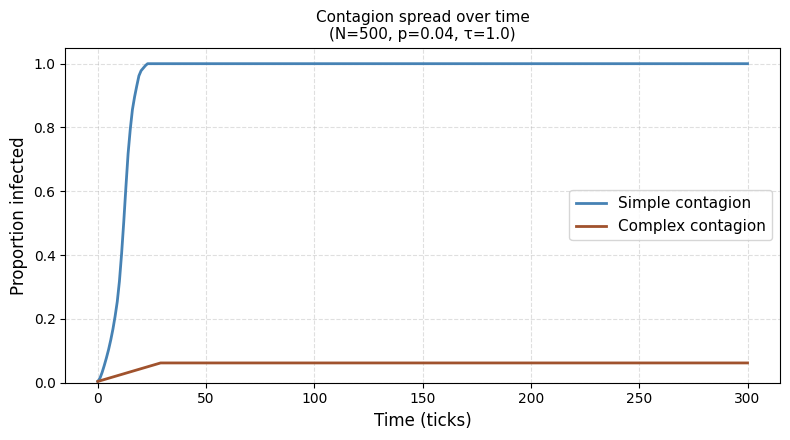

In [7]:
def run_with_history(G, prob_infection, complex_contagion, max_ticks=300, seed=None):
    """
    Run a simulation and record pct_infected at every tick.
    Used for plotting the infection curve over time.
    """
    rng = np.random.default_rng(seed)
    infected = infect_two(G, rng)
    history = [sum(infected.values()) / len(infected)]  # t=0

    for t in range(1, max_ticks + 1):
        if all(infected.values()):
            # Pad with 1.0 for remaining ticks so curves are same length.
            history += [1.0] * (max_ticks - t + 1)
            break
        infected = go(G, infected, prob_infection, complex_contagion, rng)
        history.append(sum(infected.values()) / len(infected))

    return history


# Build one small-world network shared by both runs.
G_demo = build_small_world(NUM_NODES, REWIRING_PROB, DEGREE, seed=SEED)

hist_simple  = run_with_history(G_demo, PROB_INFECTION, complex_contagion=False, seed=1)
hist_complex = run_with_history(G_demo, PROB_INFECTION, complex_contagion=True,  seed=1)

fig, ax = plt.subplots(figsize=(8, 4.5))

ticks = range(len(hist_simple))
ax.plot(ticks, hist_simple,  color='steelblue',  lw=2,   label='Simple contagion')
ax.plot(ticks, hist_complex, color='sienna',     lw=2,   label='Complex contagion')

ax.set_xlabel('Time (ticks)', fontsize=12)
ax.set_ylabel('Proportion infected', fontsize=12)
ax.set_title(
    f'Contagion spread over time\n'
    f'(N={NUM_NODES}, p={REWIRING_PROB}, τ={PROB_INFECTION})',
    fontsize=11
)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 9. Parameter Sweep — Reproducing Figure 9.12

This is the central analysis of section 9.4.

The NetLogo BehaviorSpace runs 100 replicates for each value of
`rewiring-probability` across 29 p values, for both contagion types.
We use 20 replicates and a subset of p values here for speed —
the pattern is robust.

**What to expect (Figure 9.12):**
- **Panel A (simple contagion):** time to full spread *decreases* monotonically
  as p increases. More random ties = faster spread.
- **Panel B (complex contagion):** proportion infected *decreases* sharply
  as p increases. More random ties = contagion gets stuck at structural gaps.

In [8]:
# --- Sweep parameters ---
# Local variables: p_values, n_reps, results_simple, results_complex.
p_values = [
    0, 0.001, 0.002, 0.003, 0.005, 0.007,
    0.01, 0.02, 0.03, 0.05, 0.07,
    0.1, 0.2, 0.3, 0.5, 0.7, 1.0
]
n_reps  = 20   # BehaviorSpace uses 100; 20 is much faster and shows the same pattern
N_sweep = 500  # matches the BehaviorSpace experiment

results_simple  = []   # list of (p, mean_ticks, std_ticks) per p value
results_complex = []   # list of (p, mean_pct, std_pct) per p value

print("Running sweep... (this may take a minute)")
for p in p_values:
    ticks_list, pct_list = [], []
    for rep in range(n_reps):
        # Build a fresh network for each replicate (same seed structure as NetLogo).
        # Network seed and simulation seed are kept separate.
        G = build_small_world(N_sweep, p, DEGREE, seed=rep * 100)

        t, _   = run_simulation(G, PROB_INFECTION, complex_contagion=False,
                                 max_ticks=MAX_TICKS, seed=rep)
        _, pct = run_simulation(G, PROB_INFECTION, complex_contagion=True,
                                 max_ticks=MAX_TICKS, seed=rep + 10000)

        ticks_list.append(t)
        pct_list.append(pct)

    results_simple.append((p, np.mean(ticks_list), np.std(ticks_list)))
    results_complex.append((p, np.mean(pct_list),  np.std(pct_list)))

print("Sweep complete.")

Running sweep... (this may take a minute)
Sweep complete.


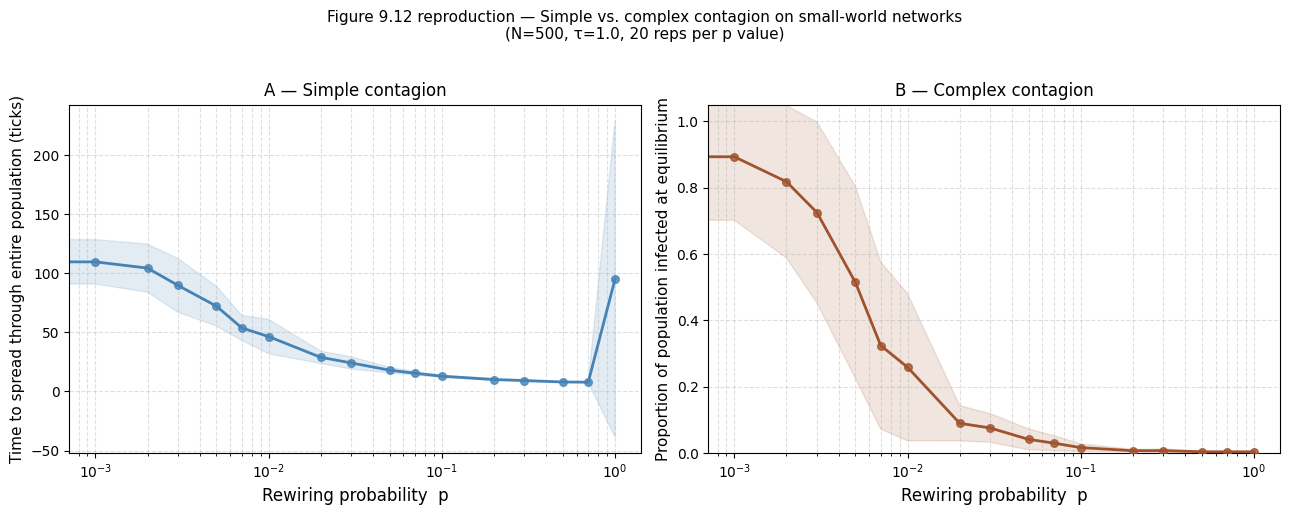


Key results:
  Simple contagion: time to spread DECREASES with more rewiring (more shortcuts).
  Complex contagion: proportion infected DECREASES with more rewiring.
  Interpretation: random long-range ties create structural gaps that
  break the cluster-to-cluster spread required by complex contagion.


In [9]:
# --- Plot Figure 9.12 ---
# Panel A: time to spread (simple contagion) vs. rewiring probability.
# Panel B: proportion infected at equilibrium (complex contagion) vs. rewiring probability.

ps_s,   means_s,  stds_s  = zip(*results_simple)
ps_c,   means_c,  stds_c  = zip(*results_complex)

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    f'Figure 9.12 reproduction — Simple vs. complex contagion on small-world networks\n'
    f'(N={N_sweep}, τ={PROB_INFECTION}, {n_reps} reps per p value)',
    fontsize=11, y=1.02
)

# --- Panel A: Simple contagion — time to spread ---
ax_a.scatter(ps_s, means_s, color='steelblue', s=30, zorder=3, alpha=0.8)
ax_a.plot(ps_s, means_s, color='steelblue', lw=2)
ax_a.fill_between(ps_s,
                  [m - s for m, s in zip(means_s, stds_s)],
                  [m + s for m, s in zip(means_s, stds_s)],
                  alpha=0.15, color='steelblue')
ax_a.set_xscale('log')
ax_a.set_xlabel('Rewiring probability  p', fontsize=12)
ax_a.set_ylabel('Time to spread through entire population (ticks)', fontsize=11)
ax_a.set_title('A — Simple contagion', fontsize=12)
ax_a.grid(True, which='both', linestyle='--', alpha=0.4)

# --- Panel B: Complex contagion — proportion infected ---
ax_b.scatter(ps_c, means_c, color='sienna', s=30, zorder=3, alpha=0.8)
ax_b.plot(ps_c, means_c, color='sienna', lw=2)
ax_b.fill_between(ps_c,
                  [m - s for m, s in zip(means_c, stds_c)],
                  [m + s for m, s in zip(means_c, stds_c)],
                  alpha=0.15, color='sienna')
ax_b.set_xscale('log')
ax_b.set_xlabel('Rewiring probability  p', fontsize=12)
ax_b.set_ylabel('Proportion of population infected at equilibrium', fontsize=11)
ax_b.set_title('B — Complex contagion', fontsize=12)
ax_b.set_ylim(0, 1.05)
ax_b.grid(True, which='both', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print("\nKey results:")
print("  Simple contagion: time to spread DECREASES with more rewiring (more shortcuts).")
print("  Complex contagion: proportion infected DECREASES with more rewiring.")
print("  Interpretation: random long-range ties create structural gaps that")
print("  break the cluster-to-cluster spread required by complex contagion.")

## 10. Why Does Complex Contagion Fail at High Rewiring?

A brief conceptual illustration. The problem is **structural gaps**:
when communities are connected by only a single edge, a susceptible node
on the receiving end of that edge can only ever have *one* infected neighbor
from that community — never meeting the threshold of two required for
complex contagion.

Here we visualize this with a tiny example.

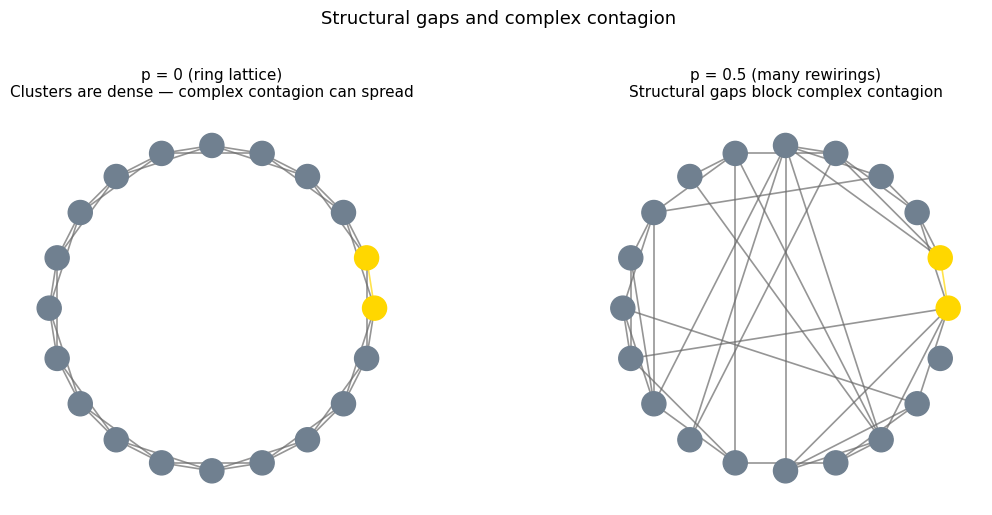

In [10]:
# Build a small network at two extremes to illustrate structural gaps.
N_illus = 20

G_low_p  = build_small_world(N_illus, rewiring_prob=0.0,  seed=5)
G_high_p = build_small_world(N_illus, rewiring_prob=0.5,  seed=5)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
configs = [
    (G_low_p,  'p = 0 (ring lattice)\nClusters are dense — complex contagion can spread'),
    (G_high_p, 'p = 0.5 (many rewirings)\nStructural gaps block complex contagion'),
]

for ax, (net, title) in zip(axes, configs):
    pos = nx.circular_layout(sorted(net.nodes()))
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=11, pad=10)

    # Highlight two seed nodes and their shared edge in yellow.
    # Pick node 0 and node 1 as a demonstration.
    seed_nodes  = [0, 1]
    seed_color  = ['gold' if n in seed_nodes else 'slategray' for n in sorted(net.nodes())]
    edge_colors = ['gold' if (u in seed_nodes and v in seed_nodes) else 'dimgray'
                   for u, v in net.edges()]

    nx.draw_networkx_edges(net, pos, edge_color=edge_colors, width=1.2, alpha=0.7, ax=ax)
    nx.draw_networkx_nodes(net, pos, node_color=seed_color, node_size=300, ax=ax)

fig.suptitle('Structural gaps and complex contagion', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 11. Summary

| Contagion type | Effect of more rewiring |
|---|---|
| Simple | Spreads **faster** — long-range ties create shortcuts |
| Complex | Spreads **less** — structural gaps break multi-contact requirement |

This is the fundamental tension explored in section 9.4 of the book.
It has real empirical consequences: health behaviors, norms, and other
content requiring social reinforcement may spread *better* through
tightly clustered networks than through networks with many random ties
(Centola, 2010).